In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load raw business data
data_path = Path("../data/raw_business_data.csv")
df = pd.read_csv(data_path)

print("Dataset loaded successfully.")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

df.head()

Dataset loaded successfully.
Rows: 678,013
Columns: 12


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,'Diesel',76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,'Diesel',76,R72


In [3]:
# Structural audit
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (678013, 12)

Column names:
['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']

Missing values:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64


In [4]:
# Cell 3: Raw data audit
df.info()

df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   IDpol       678013 non-null  float64
 1   ClaimNb     678013 non-null  int64  
 2   Exposure    678013 non-null  float64
 3   Area        678013 non-null  str    
 4   VehPower    678013 non-null  int64  
 5   VehAge      678013 non-null  int64  
 6   DrivAge     678013 non-null  int64  
 7   BonusMalus  678013 non-null  int64  
 8   VehBrand    678013 non-null  str    
 9   VehGas      678013 non-null  str    
 10  Density     678013 non-null  int64  
 11  Region      678013 non-null  str    
dtypes: float64(2), int64(6), str(4)
memory usage: 71.7 MB


,count,mean,std,min,25%,50%,75%,max
IDpol,678013.0,2.621857e+06,1.641783e+06,1.000000,1157951.00,2272152.00,4046274.00,6114330.00
ClaimNb,678013.0,5.324677e-02,2.401173e-01,0.000000,0.00,0.00,0.00,16.00
Exposure,678013.0,5.287501e-01,3.644415e-01,0.002732,0.18,0.49,0.99,2.01
VehPower,678013.0,6.454631e+00,2.050906e+00,4.000000,5.00,6.00,7.00,15.00
VehAge,678013.0,7.044265e+00,5.666232e+00,0.000000,2.00,6.00,11.00,100.00
DrivAge,678013.0,4.549912e+01,1.413744e+01,18.000000,34.00,44.00,55.00,100.00
BonusMalus,678013.0,5.976150e+01,1.563666e+01,50.000000,50.00,50.00,64.00,230.00
Density,678013.0,1.792422e+03,3.958647e+03,1.000000,92.00,393.00,1658.00,27000.00


In [5]:
# Cell 4: Audit key numeric variables

audit_columns = ["DrivAge", "Exposure", "BonusMalus"]

df[audit_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
DrivAge,678013.0,45.499122,14.137444,18.000000,34.00,44.00,55.00,100.00
Exposure,678013.0,0.528750,0.364442,0.002732,0.18,0.49,0.99,2.01
BonusMalus,678013.0,59.761502,15.636658,50.000000,50.00,50.00,64.00,230.00


In [6]:
# Cell 5: Check invalid values

print("DrivAge < 18:", (df["DrivAge"] < 18).sum())
print("Exposure <= 0:", (df["Exposure"] <= 0).sum())
print("Exposure > 1:", (df["Exposure"] > 1).sum())
print("BonusMalus < 50:", (df["BonusMalus"] < 50).sum())

print("\nMaximum values:")
print("DrivAge max:", df["DrivAge"].max())
print("Exposure max:", df["Exposure"].max())
print("BonusMalus max:", df["BonusMalus"].max())

DrivAge < 18: 0
Exposure <= 0: 0
Exposure > 1: 1224
BonusMalus < 50: 0

Maximum values:
DrivAge max: 100
Exposure max: 2.01
BonusMalus max: 230


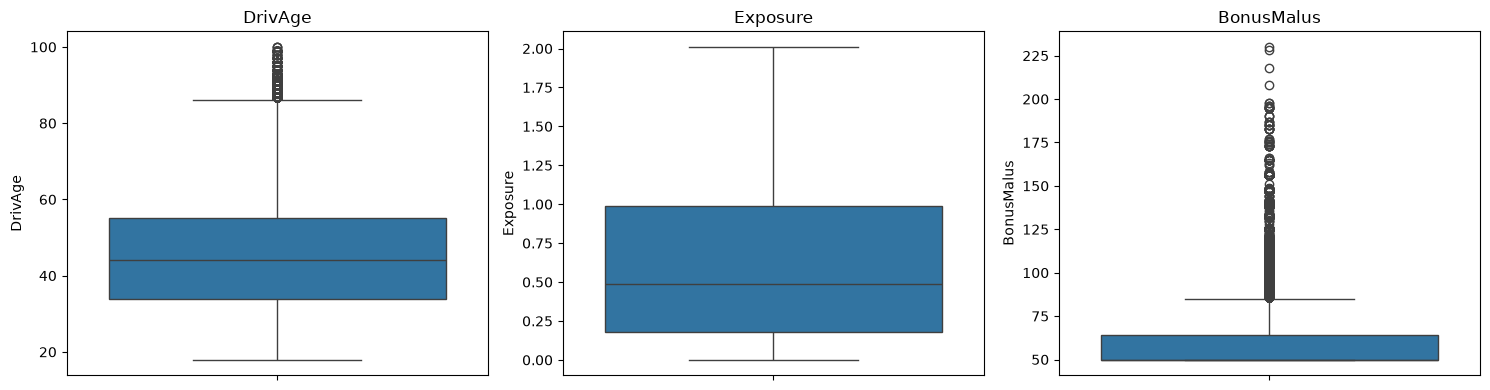

In [7]:
# Cell 6: Visual audit of key numeric variables

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(y=df["DrivAge"], ax=axes[0])
axes[0].set_title("DrivAge")

sns.boxplot(y=df["Exposure"], ax=axes[1])
axes[1].set_title("Exposure")

sns.boxplot(y=df["BonusMalus"], ax=axes[2])
axes[2].set_title("BonusMalus")

plt.tight_layout()
plt.show()

In [8]:
# Cell 7: IQR outlier audit

for col in ["DrivAge", "Exposure", "BonusMalus"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Lower bound: {lower_bound:.2f}")
    print(f"  Upper bound: {upper_bound:.2f}")
    print(f"  Number of outliers: {len(outliers):,}")
    print(f"  Percentage: {len(outliers) / len(df) * 100:.2f}%")
    print()

DrivAge
  Q1: 34.00
  Q3: 55.00
  IQR: 21.00
  Lower bound: 2.50
  Upper bound: 86.50
  Number of outliers: 1,275
  Percentage: 0.19%

Exposure
  Q1: 0.18
  Q3: 0.99
  IQR: 0.81
  Lower bound: -1.04
  Upper bound: 2.21
  Number of outliers: 0
  Percentage: 0.00%

BonusMalus
  Q1: 50.00
  Q3: 64.00
  IQR: 14.00
  Lower bound: 29.00
  Upper bound: 85.00
  Number of outliers: 62,384
  Percentage: 9.20%



In [9]:
# Cell 8: Examine extreme values

for col in ["DrivAge", "Exposure", "BonusMalus"]:
    print(f"\n{col}")
    print(df[col].quantile([0, 0.01, 0.05, 0.50, 0.95, 0.99, 1.00]))


DrivAge
0.00     18.0
0.01     20.0
0.05     25.0
0.50     44.0
0.95     72.0
0.99     80.0
1.00    100.0
Name: DrivAge, dtype: float64

Exposure
0.00    0.002732
0.01    0.008219
0.05    0.040000
0.50    0.490000
0.95    1.000000
0.99    1.000000
1.00    2.010000
Name: Exposure, dtype: float64

BonusMalus
0.00     50.0
0.01     50.0
0.05     50.0
0.50     50.0
0.95     95.0
0.99    106.0
1.00    230.0
Name: BonusMalus, dtype: float64


In [10]:
# Cell 9: Apply cleaning rules

df_clean = df.copy()

# Keep only plausible driver ages
df_clean = df_clean[
    (df_clean["DrivAge"] >= 18) &
    (df_clean["DrivAge"] <= 100)
].copy()

# Cap Exposure at 1 year
df_clean["Exposure"] = df_clean["Exposure"].clip(upper=1.0)

# Cap BonusMalus at the 99th percentile
bonusmalus_cap = df["BonusMalus"].quantile(0.99)
df_clean["BonusMalus"] = df_clean["BonusMalus"].clip(upper=bonusmalus_cap)

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

print("\nCleaned maximum values:")
print("DrivAge max:", df_clean["DrivAge"].max())
print("Exposure max:", df_clean["Exposure"].max())
print("BonusMalus max:", df_clean["BonusMalus"].max())

Original rows: 678013
Cleaned rows: 678013
Rows removed: 0

Cleaned maximum values:
DrivAge max: 100
Exposure max: 1.0
BonusMalus max: 106


In [11]:
# Cell 10: Create data dictionary

data_dictionary = pd.DataFrame({
    "Variable": df_clean.columns,
    "Data_Type": df_clean.dtypes.astype(str).values,
    "Missing_Values": df_clean.isnull().sum().values,
    "Unique_Values": df_clean.nunique().values
})

data_dictionary

,Variable,Data_Type,Missing_Values,Unique_Values
0,IDpol,float64,0,678013
1,ClaimNb,int64,0,11
2,Exposure,float64,0,106
3,Area,str,0,6
4,VehPower,int64,0,12
5,VehAge,int64,0,78
6,DrivAge,int64,0,83
7,BonusMalus,int64,0,57
8,VehBrand,str,0,11
9,VehGas,str,0,2


In [12]:
# Cell 11: Complete data dictionary

descriptions = {
    "IDpol": "Unique policy identifier",
    "ClaimNb": "Number of claims",
    "Exposure": "Policy exposure period",
    "Area": "Area code",
    "VehPower": "Vehicle power",
    "VehAge": "Vehicle age",
    "DrivAge": "Driver age",
    "BonusMalus": "Bonus-malus rating",
    "VehBrand": "Vehicle brand category",
    "VehGas": "Vehicle fuel type",
    "Density": "Population density",
    "Region": "Region code"
}

roles = {
    "IDpol": "Identifier",
    "ClaimNb": "Target",
    "Exposure": "Numeric feature",
    "Area": "Categorical feature",
    "VehPower": "Numeric feature",
    "VehAge": "Numeric feature",
    "DrivAge": "Numeric feature",
    "BonusMalus": "Numeric feature",
    "VehBrand": "Categorical feature",
    "VehGas": "Categorical feature",
    "Density": "Numeric feature",
    "Region": "Categorical feature"
}

data_dictionary["Description"] = data_dictionary["Variable"].map(descriptions)
data_dictionary["Role"] = data_dictionary["Variable"].map(roles)

data_dictionary

,Variable,Data_Type,Missing_Values,Unique_Values,Description,Role
0,IDpol,float64,0,678013,Unique policy identifier,Identifier
1,ClaimNb,int64,0,11,Number of claims,Target
2,Exposure,float64,0,106,Policy exposure period,Numeric feature
3,Area,str,0,6,Area code,Categorical feature
4,VehPower,int64,0,12,Vehicle power,Numeric feature
5,VehAge,int64,0,78,Vehicle age,Numeric feature
6,DrivAge,int64,0,83,Driver age,Numeric feature
7,BonusMalus,int64,0,57,Bonus-malus rating,Numeric feature
8,VehBrand,str,0,11,Vehicle brand category,Categorical feature
9,VehGas,str,0,2,Vehicle fuel type,Categorical feature


In [13]:
# Cell 12: Save data dictionary

dictionary_path = Path("../reports/data_dictionary.csv")

data_dictionary.to_csv(dictionary_path, index=False)

print(f"Data dictionary saved to: {dictionary_path}")

Data dictionary saved to: ../reports/data_dictionary.csv


In [14]:
# Cell 13: Examine ClaimNb distribution

print("ClaimNb value counts:")
print(df["ClaimNb"].value_counts().sort_index())

print("\nClaimNb percentiles:")
print(df["ClaimNb"].quantile([0, 0.50, 0.90, 0.95, 0.99, 1.00]))

print("\nClaimNb summary:")
print(df["ClaimNb"].describe())

ClaimNb value counts:
ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

ClaimNb percentiles:
0.00     0.0
0.50     0.0
0.90     0.0
0.95     1.0
0.99     1.0
1.00    16.0
Name: ClaimNb, dtype: float64

ClaimNb summary:
count    678013.000000
mean          0.053247
std           0.240117
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          16.000000
Name: ClaimNb, dtype: float64


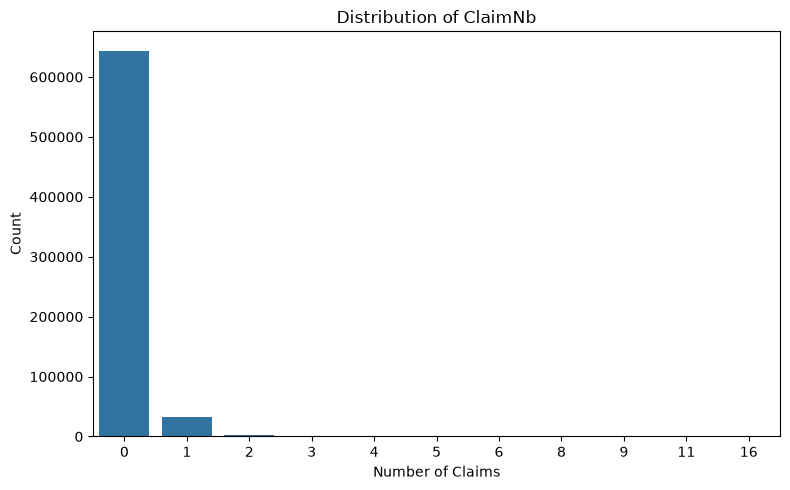

In [15]:
# Cell 14: Visualize ClaimNb distribution

plt.figure(figsize=(8, 5))
sns.countplot(x="ClaimNb", data=df)

plt.title("Distribution of ClaimNb")
plt.xlabel("Number of Claims")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### ClaimNb Outlier Decision

ClaimNb represents the number of claims associated with an insurance policy. The distribution is highly right-skewed, with most observations having zero claims. The median and 90th percentile are 0, while the 95th and 99th percentiles are 1. Although a small number of policies have much higher ClaimNb values, these observations are plausible because some policyholders may experience multiple claims.

Therefore, high ClaimNb values are retained rather than removed as outliers. Removing them could eliminate rare but meaningful insurance claim behavior and reduce the usefulness of the data for risk analysis.

In [16]:
# Cell 16: Examine Density distribution

print("Density percentiles:")
print(df["Density"].quantile([0, 0.50, 0.90, 0.95, 0.99, 1.00]))

print("\nDensity summary:")
print(df["Density"].describe())

Density percentiles:
0.00        1.0
0.50      393.0
0.90     4128.0
0.95     7313.0
0.99    27000.0
1.00    27000.0
Name: Density, dtype: float64

Density summary:
count    678013.000000
mean       1792.422405
std        3958.646564
min           1.000000
25%          92.000000
50%         393.000000
75%        1658.000000
max       27000.000000
Name: Density, dtype: float64


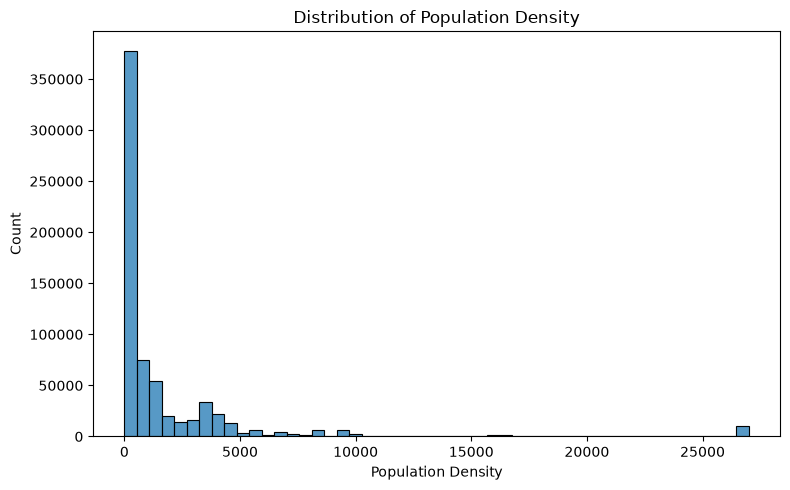

In [17]:
# Cell 17: Visualize Density distribution

plt.figure(figsize=(8, 5))
sns.histplot(df["Density"], bins=50)

plt.title("Distribution of Population Density")
plt.xlabel("Population Density")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Density Outlier Decision

Density represents the population density of the geographic area associated with each insurance policy. The distribution is strongly right-skewed, with most observations concentrated at lower density values and a small number of observations reaching 27,000.

Although these high-density values appear extreme, they are plausible because some policies may be located in highly populated urban areas. Therefore, the high Density values are retained rather than automatically removed as outliers. Removing them could eliminate valid observations and reduce the representativeness of the dataset.

In [18]:
# Cell 19: Examine categorical variables

categorical_cols = ["Area", "VehBrand", "VehGas", "Region"]

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


Area value counts:
Area
C    191880
D    151596
E    137167
A    103957
B     75459
F     17954
Name: count, dtype: int64

VehBrand value counts:
VehBrand
B12    166024
B1     162736
B2     159861
B3      53395
B5      34753
B6      28548
B4      25179
B10     17707
B11     13585
B13     12178
B14      4047
Name: count, dtype: int64

VehGas value counts:
VehGas
'Regular'    345877
'Diesel'     332136
Name: count, dtype: int64

Region value counts:
Region
R24    160601
R82     84752
R93     79315
R11     69791
R53     42122
R52     38751
R91     35805
R72     31329
R31     27285
R54     19046
R73     17141
R41     12990
R25     10893
R26     10492
R23      8784
R22      7994
R83      5287
R74      4567
R94      4516
R21      3026
R42      2200
R43      1326
Name: count, dtype: int64


In [19]:
# Cell 20: Summarize categorical variables

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Area: 6 unique values
VehBrand: 11 unique values
VehGas: 2 unique values
Region: 22 unique values


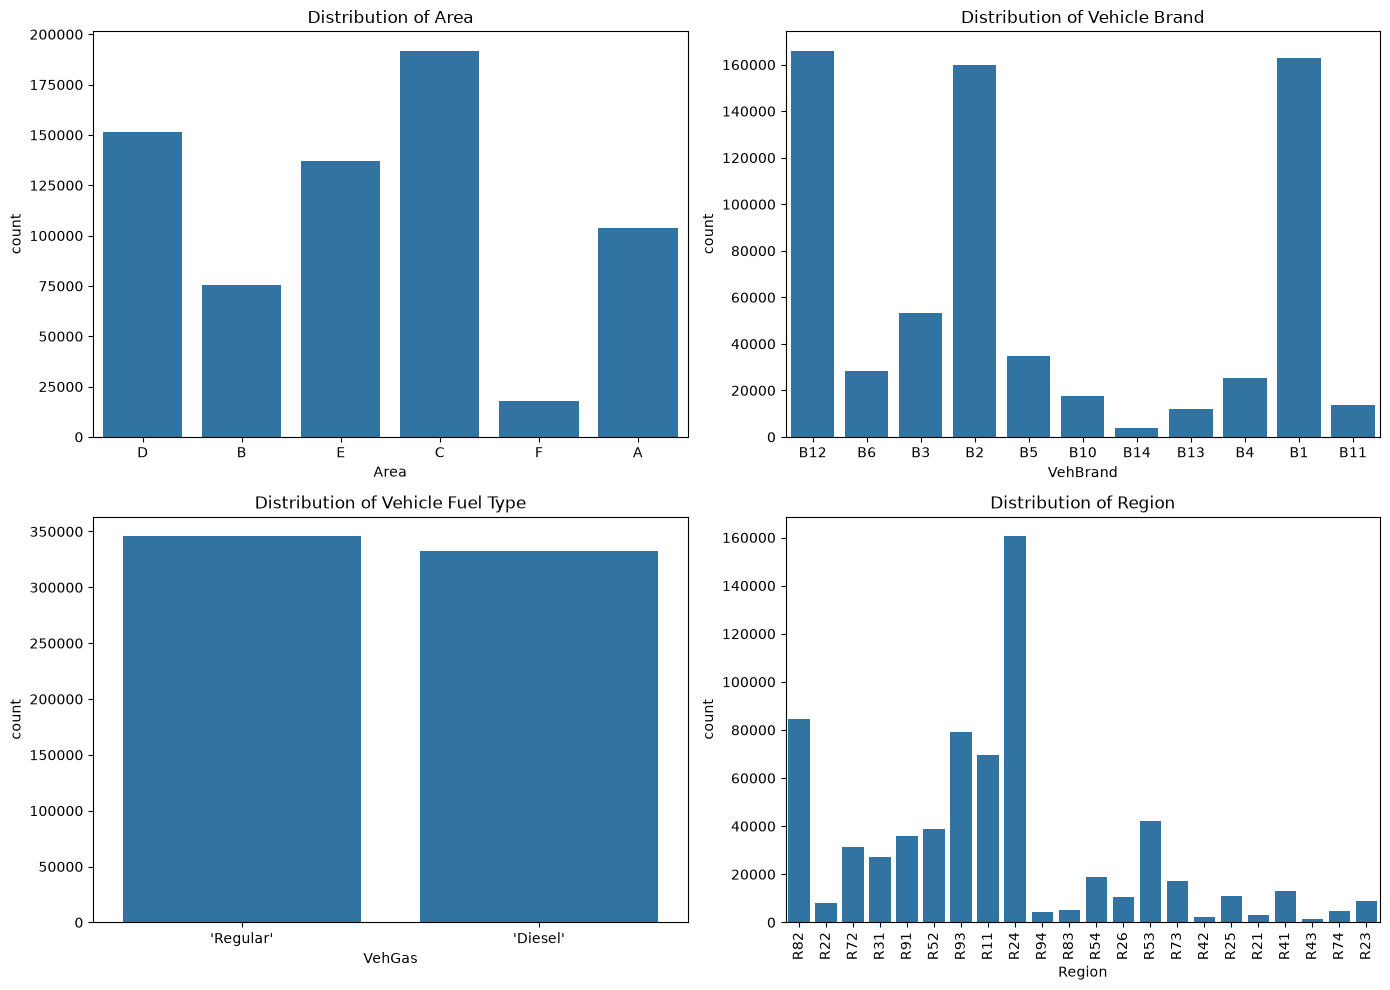

In [20]:
# Cell 21: Visualize categorical variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x="Area", data=df, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Area")

sns.countplot(x="VehBrand", data=df, ax=axes[0, 1])
axes[0, 1].set_title("Distribution of Vehicle Brand")

sns.countplot(x="VehGas", data=df, ax=axes[1, 0])
axes[1, 0].set_title("Distribution of Vehicle Fuel Type")

sns.countplot(x="Region", data=df, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of Region")
axes[1, 1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [21]:
# Cell 22: Check duplicate rows

duplicate_count = df.duplicated().sum()
duplicate_percentage = (duplicate_count / len(df)) * 100

print("Duplicate rows:", duplicate_count)
print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


In [22]:
# Cell 23: Final data quality summary

print("FINAL DATA QUALITY SUMMARY")
print("-" * 35)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\nData types:")
print(df.dtypes)

FINAL DATA QUALITY SUMMARY
-----------------------------------
Rows: 678,013
Columns: 12
Missing values: 0
Duplicate rows: 0

Data types:
IDpol         float64
ClaimNb         int64
Exposure      float64
Area              str
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand          str
VehGas            str
Density         int64
Region            str
dtype: object


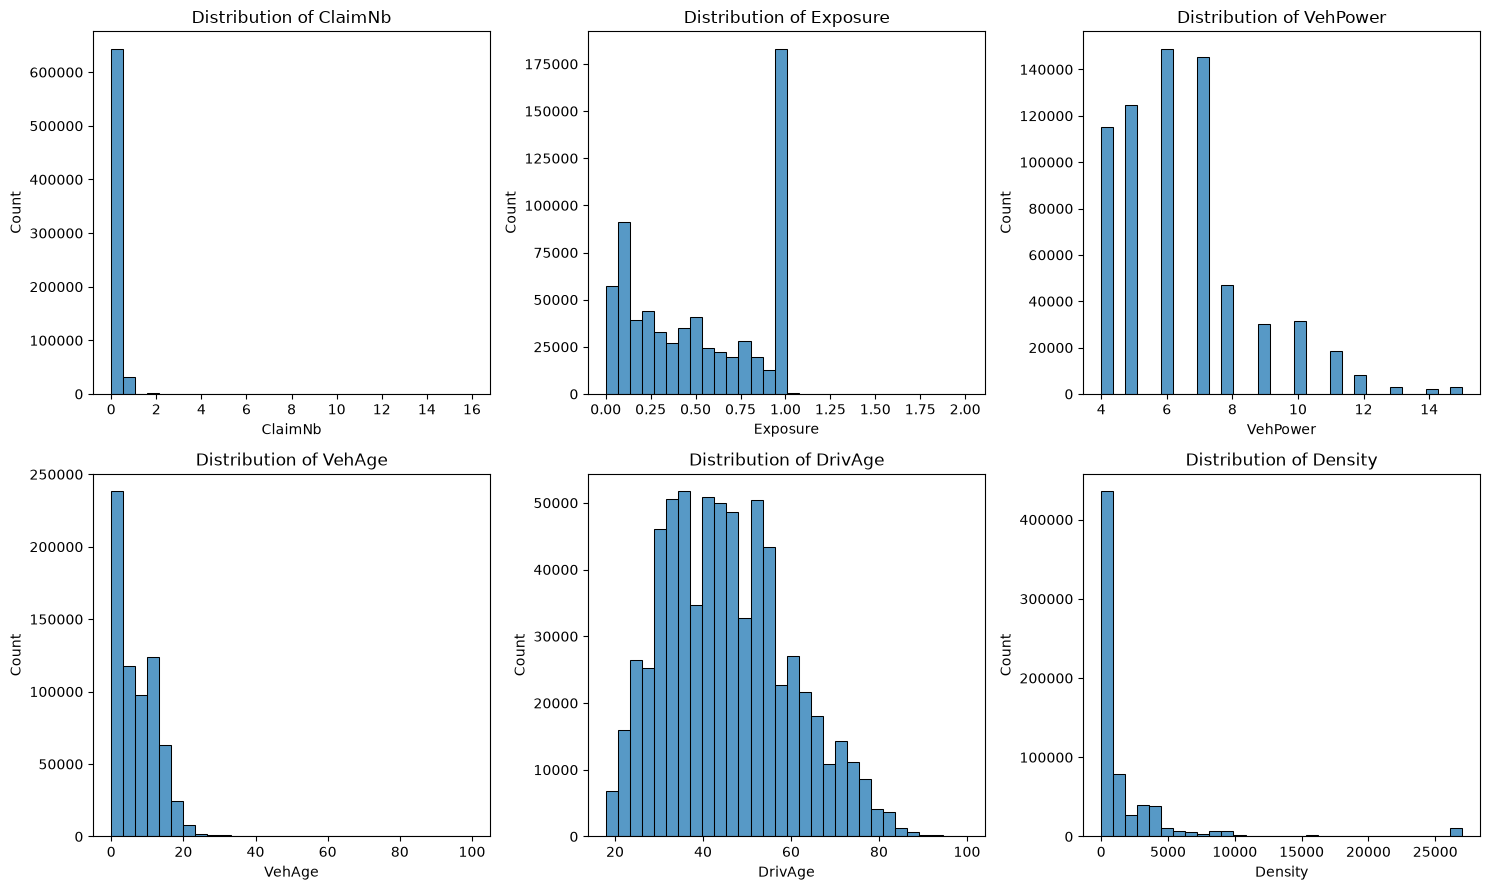

In [23]:
# Cell 24: Create feature distribution plots

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

features = ["ClaimNb", "Exposure", "VehPower", "VehAge", "DrivAge", "Density"]

for ax, feature in zip(axes.flatten(), features):
    sns.histplot(df[feature], bins=30, ax=ax)
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

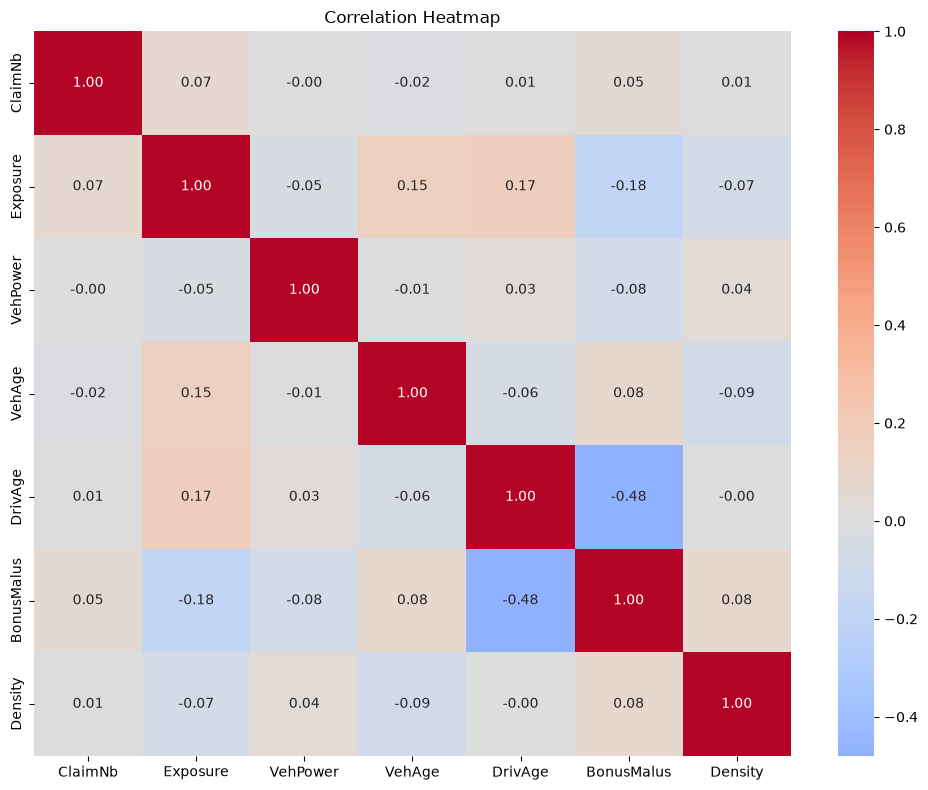

In [24]:
# Cell 25: Create correlation heatmap

numeric_cols = [
    "ClaimNb", "Exposure", "VehPower",
    "VehAge", "DrivAge", "BonusMalus", "Density"
]

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "../reports/figures/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Business Interpretation: Exposure, Density, and Area

Exposure represents the amount of time that each insurance policy is active and therefore acts as a rate offset when modeling claim frequency. Policies with longer exposure periods naturally have more opportunity to generate claims, so exposure should be incorporated into the model rather than treated as a standard predictor.

Density and Area should not both be included in the same linear regression model because they represent closely related geographic information. Density is a continuous measure of population density, while Area is a categorical representation of geographic density levels. Including both may introduce redundant information and multicollinearity into the model.

## Executive Defense: Why ClaimNb Should Not Be Log-Transformed

ClaimNb should remain in its original count form rather than being log-transformed. It is a discrete count variable with a large number of zero values, representing policies with no reported claims. A log transformation would be problematic because log(0) is undefined and would require an artificial adjustment such as adding 1.

More importantly, ClaimNb represents the actual number of claims associated with each policy. Preserving the original count scale maintains its business meaning and makes the variable easier to interpret. Therefore, ClaimNb is retained in its original form.

## Distribution Plot Interpretations

### ClaimNb
- The distribution is highly concentrated at zero, indicating that most insurance policies have no claims.
- Only a small proportion of policies have one or more claims, producing a strongly right-skewed distribution.
- Because ClaimNb is a discrete count variable, keeping it in its original form preserves its business interpretation.

### Exposure
- Exposure values are concentrated at lower values, with fewer observations as exposure increases.
- The distribution is right-skewed, showing that relatively fewer policies have long exposure periods.
- Exposure represents the amount of time a policy is active and should be treated as a rate offset when modeling claim frequency.

### VehPower
- Vehicle power is concentrated within a relatively narrow range, while higher-power vehicles occur less frequently.
- The distribution is not symmetric and shows greater concentration among lower-to-middle vehicle power values.
- VehPower may help explain differences in insurance risk associated with vehicle characteristics.

### VehAge
- Most vehicles are relatively young, while progressively fewer observations occur at higher vehicle ages.
- The distribution is strongly right-skewed because a small number of vehicles are substantially older than most vehicles.
- Extreme vehicle ages should be examined carefully, but plausible values should not automatically be removed.

### DrivAge
- Driver age is concentrated among adult and middle-aged drivers, with fewer observations at the youngest and oldest ages.
- The distribution is unimodal and positively skewed toward older driver ages.
- Driver age may be an important risk-related feature because driving behavior and insurance risk can vary across age groups.

### Density
- Population density is strongly right-skewed, with most observations concentrated at relatively low density values.
- A small number of observations have very high population density, creating a long right tail.
- High-density observations may represent legitimate urban areas, so extreme values should be evaluated in context before removal.

## Correlation Heatmap Interpretation

- Most numerical variables have weak correlations with one another, suggesting limited linear relationships among the predictors.
- The strongest relationship is between DrivAge and BonusMalus, with a correlation of approximately -0.48, indicating a moderate negative relationship.
- ClaimNb has only weak correlations with the numerical predictors, suggesting that no single numerical feature has a strong linear relationship with the number of claims.